# chemagent — Debugging Notebook

End-to-end pipeline using the consolidated `chemagent_mcp.py` server.

**Preferred workflow (data stays on disk)**
```
load_dataset → featurize_dataset → split_prepared_dataset → build_model_from_split_file
```

## 1. Environment setup

In [28]:
import sys
from pathlib import Path

# Resolve workspace root (works whether cwd is notebooks/ or the repo root)
_ws_root = Path.cwd()
if not (_ws_root / "src").exists():
    _ws_root = _ws_root.parent

_servers_dir = _ws_root / "src" / "chemagent" / "servers"

for _p in [str(_ws_root), str(_servers_dir)]:
    if _p not in sys.path:
        sys.path.insert(0, _p)

print(f"Workspace root : {_ws_root}")
print(f"Servers dir    : {_servers_dir}")

Workspace root : c:\Users\janela\OneDrive - uni-bonn.de\Code\AI-Agent-for-Compound-Selectivity-Prediction-and-Explainability
Servers dir    : c:\Users\janela\OneDrive - uni-bonn.de\Code\AI-Agent-for-Compound-Selectivity-Prediction-and-Explainability\src\chemagent\servers


## 2. Imports

In [29]:
import matplotlib.pyplot as plt
%matplotlib inline

from src.chemagent.servers.chemagent_mcp import (
    # ── Dataset tools ──────────────────────────────────────────
    list_available_datasets,
    list_loaded_datasets,
    list_featurizers,
    load_dataset,
    get_dataset_info,
    featurize_dataset,
    split_prepared_dataset,
    load_split,
    # ── ML tools ───────────────────────────────────────────────
    get_available_algorithms,
    get_recommended_metrics,
    build_model_from_split_file,
    evaluate_classification,
    evaluate_regression,
    predict,
)
from src.chemagent.plots import (
    set_theme,
    plot_confusion_matrix,
    plot_roc_curve,
    plot_pr_curve,
    plot_metric_bar,
    plot_feature_importance,
    plot_class_distribution,
    plot_split_statistics,
)

## 3. Discover available options

In [30]:
list_available_datasets()

{'datasets': ['chembl_activity_data_O00329_P42336.csv',
  'chembl_activity_data_O00329_P48736.csv',
  'chembl_activity_data_P42336_P48736.csv'],
 'count': 3,
 'directory': 'C:\\Users\\janela\\OneDrive - uni-bonn.de\\Code\\AI-Agent-for-Compound-Selectivity-Prediction-and-Explainability\\data\\datasets'}

In [31]:
list_featurizers()

{'ECFP': {'parameters': {'n_bits': '2048', 'radius': '2', 'sparse': 'False'},
  'description': 'Generate ECFP (Morgan) bit-vector fingerprints from SMILES strings.'},
 'MACCS': {'parameters': {},
  'description': 'Generate 166-bit MACCS structural-key fingerprints from SMILES strings.'},
 'RDKitFP': {'parameters': {'n_bits': '2048',
   'min_path': '1',
   'max_path': '7'},
  'description': 'Generate RDKit topological (path-based) fingerprints.'},
 'AtomPairFP': {'parameters': {'n_bits': '2048'},
  'description': 'Generate atom-pair fingerprints.'},
 'TopologicalTorsionFP': {'parameters': {'n_bits': '2048'},
  'description': 'Generate topological-torsion fingerprints.'}}

In [32]:
get_available_algorithms()

{'RFR': {'name': 'Random Forest Regressor',
  'task_type': 'regression',
  'hyperparameters': {'n_estimators': [50, 100, 200],
   'max_features': ['sqrt', 'log2'],
   'min_samples_split': [2, 5, 10],
   'min_samples_leaf': [1, 2, 4]},
  'supports_multiclass': False,
  'supports_class_weight': False,
  'description': 'Ensemble of decision trees for regression tasks'},
 'RFC': {'name': 'Random Forest Classifier',
  'task_type': 'classification',
  'hyperparameters': {'n_estimators': [50, 100, 200],
   'max_features': ['sqrt', 'log2'],
   'min_samples_split': [2, 5, 10],
   'min_samples_leaf': [1, 2, 4]},
  'supports_multiclass': True,
  'supports_class_weight': True,
  'description': 'Ensemble of decision trees for classification, handles multi-class'},
 'SVC': {'name': 'Support Vector Classifier',
  'task_type': 'classification',
  'hyperparameters': {'C': [0.1, 1, 10],
   'kernel': ['rbf', 'linear'],
   'gamma': ['scale', 'auto']},
  'supports_multiclass': True,
  'supports_class_weigh

In [33]:
get_recommended_metrics()

{'binary_classification': {'optimization': ['f1',
   'roc_auc',
   'average_precision',
   'accuracy'],
  'evaluation': ['MCC',
   'F1',
   'Precision',
   'Recall',
   'AUC',
   'Average Precision',
   'Balanced Accuracy']},
 'binary_imbalanced': {'optimization': ['f1', 'average_precision', 'roc_auc'],
  'evaluation': ['MCC', 'F1', 'Precision', 'Recall', 'Balanced Accuracy'],
  'note': "Use reg_class='classification-cw' for automatic class weighting"},
 'multiclass': {'optimization': ['f1_macro',
   'f1_weighted',
   'balanced_accuracy',
   'accuracy'],
  'evaluation': ['MCC',
   'Balanced Accuracy',
   'F1_macro',
   'F1_weighted',
   'Precision_macro',
   'Recall_macro',
   'Accuracy']},
 'regression': {'optimization': ['neg_mean_squared_error',
   'neg_root_mean_squared_error',
   'neg_mean_absolute_error',
   'r2'],
  'evaluation': ['RMSE', 'MAE', 'MSE', 'R2', 'Pearson r']}}

## 4. Load dataset

In [34]:
dataset_info = load_dataset("data/datasets/chembl_activity_data_O00329_P48736.csv")
dataset_info

{'dataset_id': 'chembl_activity_data_O00329_P48736',
 'n_samples': 1277,
 'columns': ['smiles', 'class_label', 'pPot_diff', 'target_pair', 'cid'],
 'label_col': 'class_label',
 'label_stats': {'mean': 0.28191072826938135,
  'std': 0.5268901818796558,
  'min': 0.0,
  'max': 2.0,
  'unique_values': 3},
 'has_smiles': True,
 'has_precomputed_features': False,
 'loaded': True,
 'next_step': "Call featurize_dataset(dataset_id='chembl_activity_data_O00329_P48736', method='ECFP', radius=2, n_bits=2048) to compute fingerprints server-side, then split_prepared_dataset().",
 'smiles_sample': ['CC(NC(=O)c1c(N)nn2cccnc12)c1cc2cccc(Cl)c2c(=O)n1-c1ccc(O)cc1',
  'Cc1cccc(NS(=O)(=O)c2ccc(C)c(-c3cnc(N)c(-c4cnn(C)c4)c3)c2)n1',
  'Cc1ccc(S(=O)(=O)NCC(C)(C)O)cc1-c1cnc(N)c(-c2ncco2)c1']}

In [35]:
get_dataset_info(dataset_info["dataset_id"])

{'dataset_id': 'chembl_activity_data_O00329_P48736',
 'loaded': True,
 'raw_data': {'n_samples': 1277,
  'columns': ['smiles', 'class_label', 'pPot_diff', 'target_pair', 'cid'],
  'label_col': 'class_label',
  'smiles_col': 'smiles',
  'id_col': None},
 'prepared': True,
 'ml_ready': {'n_samples': 1277,
  'n_features': 167,
  'label_column': 'class_label',
  'has_smiles': True,
  'has_cid': False}}

## 5. Featurize (server-side — no large arrays transferred)

In [37]:
featurized = featurize_dataset(
    dataset_info["dataset_id"],
    method="ECFP",
    radius=2,
    n_bits=2048,

)
featurized

{'dataset_id': 'chembl_activity_data_O00329_P48736',
 'method': 'ECFP',
 'n_samples': 1277,
 'n_features': 2048,
 'label_stats': {'mean': 0.28191072826938135,
  'std': 0.5268901818796558,
  'min': 0.0,
  'max': 2.0,
  'unique_values': 3},
 'prepared': True,
 'next_step': "Call split_prepared_dataset('chembl_activity_data_O00329_P48736', train_size=0.7, val_size=0.0, test_size=0.3, stratified=True) to create splits."}

## 6. Split

In [46]:
data_splits = split_prepared_dataset(
    dataset_info["dataset_id"],
    train_size=0.7,
    val_size=0.0,
    test_size=0.3,
    stratified=True,
    split_type="scaffold",
)
data_splits

{'train': {'n_samples': 895,
  'indices': [457,
   380,
   1182,
   152,
   840,
   400,
   783,
   435,
   638,
   754,
   2,
   959,
   348,
   1095,
   811,
   247,
   108,
   466,
   80,
   43,
   486,
   284,
   200,
   118,
   612,
   925,
   243,
   522,
   672,
   822,
   841,
   405,
   623,
   675,
   847,
   458,
   13,
   267,
   347,
   618,
   786,
   990,
   1161,
   1204,
   1219,
   1226,
   1227,
   1239,
   1259,
   1270,
   853,
   230,
   252,
   278,
   488,
   501,
   609,
   636,
   816,
   861,
   1128,
   227,
   429,
   924,
   747,
   182,
   205,
   551,
   1114,
   1164,
   1212,
   1213,
   1216,
   1229,
   1232,
   1250,
   1255,
   1256,
   1258,
   767,
   446,
   1157,
   470,
   166,
   297,
   1060,
   299,
   681,
   1151,
   314,
   385,
   436,
   974,
   403,
   929,
   745,
   189,
   1175,
   500,
   188,
   820,
   15,
   218,
   255,
   326,
   869,
   967,
   1017,
   171,
   438,
   835,
   906,
   1027,
   1049,
   9,
   742,
   785,
   

## 6b. Dataset & split visualisation

[03/02/26 15:04:15] INFO     Using categorical units to plot a list of strings that are all         category.py:224
                             parsable as floats or dates. If these strings should be plotted as                    
                             numbers, cast to the appropriate data type before plotting.                           

                    INFO     Using categorical units to plot a list of strings that are all         category.py:224
                             parsable as floats or dates. If these strings should be plotted as                    
                             numbers, cast to the appropriate data type before plotting.                           

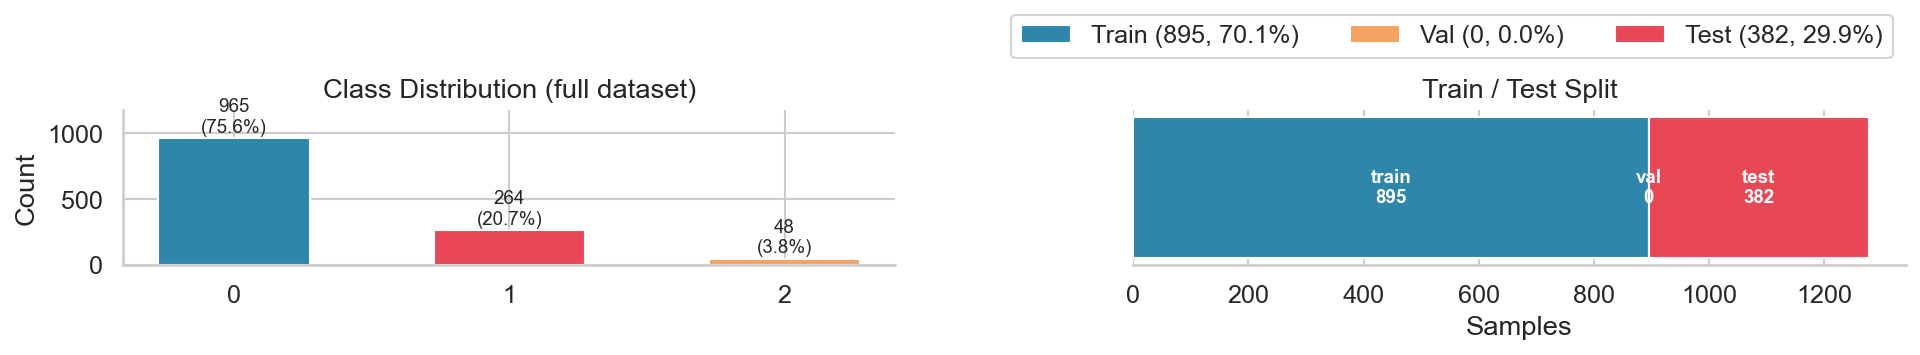

In [47]:
import joblib, numpy as np

_split = joblib.load(data_splits["saved_to"])
_all_labels = np.concatenate([_split["train_labels"], _split["test_labels"]])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

plot_class_distribution(
    _all_labels,
    title="Class Distribution (full dataset)",
    ax=axes[0],
)
plot_split_statistics(
    data_splits["statistics"],
    title="Train / Test Split",
    ax=axes[1],
)
fig.tight_layout()
plt.show()

## 7. Build model (tune → train → evaluate)

In [48]:
model_result = build_model_from_split_file(
    split_file_path=data_splits["saved_to"],
    algorithm="RFC",
    task="classification",
    )
model_result

{'algorithm': 'RFC',
 'task': 'classification',
 'cv_fold': 5,
 'opt_metric': 'balanced_accuracy',
 'best_params': {'max_features': 'sqrt',
  'min_samples_leaf': 1,
  'min_samples_split': 2,
  'n_estimators': 200},
 'cv_best_score': 0.8480128182911649,
 'model_path': 'C:\\Users\\janela\\OneDrive - uni-bonn.de\\Code\\AI-Agent-for-Compound-Selectivity-Prediction-and-Explainability\\data\\models\\chembl_activity_data_O00329_P48736_scaffold_RFC.pkl',
 'hyperparameters_searched': {'n_estimators': [50, 100, 200],
  'max_features': ['sqrt', 'log2'],
  'min_samples_split': [2, 5, 10],
  'min_samples_leaf': [1, 2, 4]},
 'train_evaluation': {'target': 'train',
  'algorithm': 'RFC',
  'overall_metrics': {'MCC': 1.0,
   'Accuracy': 1.0,
   'BA': 1.0,
   'F1 macro': 1.0,
   'F1 weighted': 1.0},
  'per_class_metrics': {'Class_0': {'Precision': 1.0,
    'Recall': 1.0,
    'F1': 1.0,
    'Support': 658},
   'Class_1': {'Precision': 1.0, 'Recall': 1.0, 'F1': 1.0, 'Support': 203},
   'Class_2': {'Precis

## 8. Inspect results

In [49]:
print("Best params  :", model_result["best_params"])
print("CV best score:", model_result["cv_best_score"])
print("Model saved  :", model_result["model_path"])

Best params  : {'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
CV best score: 0.8480128182911649
Model saved  : C:\Users\janela\OneDrive - uni-bonn.de\Code\AI-Agent-for-Compound-Selectivity-Prediction-and-Explainability\data\models\chembl_activity_data_O00329_P48736_scaffold_RFC.pkl


In [42]:
model_result["train_evaluation"]

{'target': 'train',
 'algorithm': 'RFC',
 'overall_metrics': {'MCC': 1.0,
  'Accuracy': 1.0,
  'BA': 1.0,
  'F1 macro': 1.0,
  'F1 weighted': 1.0},
 'per_class_metrics': {'Class_0': {'Precision': 1.0,
   'Recall': 1.0,
   'F1': 1.0,
   'Support': 658},
  'Class_1': {'Precision': 1.0, 'Recall': 1.0, 'F1': 1.0, 'Support': 203},
  'Class_2': {'Precision': 1.0, 'Recall': 1.0, 'F1': 1.0, 'Support': 34}},
 'confusion_matrix': [[658, 0, 0], [0, 203, 0], [0, 0, 34]],
 'class_labels': [0, 1, 2]}

In [43]:
model_result["test_evaluation"]

{'target': 'test',
 'algorithm': 'RFC',
 'overall_metrics': {'MCC': 0.6293599642063776,
  'Accuracy': 0.8900523560209425,
  'BA': 0.6814848436304088,
  'F1 macro': 0.7478699461458082,
  'F1 weighted': 0.8815621776670703},
 'per_class_metrics': {'Class_0': {'Precision': 0.9003021148036254,
   'Recall': 0.9706840390879479,
   'F1': 0.9341692789968652,
   'Support': 307},
  'Class_1': {'Precision': 0.813953488372093,
   'Recall': 0.5737704918032787,
   'F1': 0.6730769230769231,
   'Support': 61},
  'Class_2': {'Precision': 0.875,
   'Recall': 0.5,
   'F1': 0.6363636363636364,
   'Support': 14}},
 'confusion_matrix': [[298, 8, 1], [26, 35, 0], [7, 0, 7]],
 'class_labels': [0, 1, 2]}

## 9. Standalone evaluation (optional — pass custom predictions)

In [44]:
import joblib, numpy as np

split    = joblib.load(data_splits["saved_to"])
model    = joblib.load(model_result["model_path"])
X_test   = np.array(split["test_features"])
y_test   = split["test_labels"].tolist()

y_pred   = model.predict(X_test).tolist()
y_proba  = model.predict_proba(X_test).tolist()

evaluate_classification(
    labels=y_test,
    predictions=y_pred,
    probabilities=y_proba,
)

{'target': None,
 'algorithm': 'Model',
 'overall_metrics': {'MCC': 0.6293599642063776,
  'Accuracy': 0.8900523560209425,
  'BA': 0.6814848436304088,
  'F1 macro': 0.7478699461458082,
  'F1 weighted': 0.8815621776670703},
 'per_class_metrics': {'Class_0': {'Precision': 0.9003021148036254,
   'Recall': 0.9706840390879479,
   'F1': 0.9341692789968652,
   'Support': 307},
  'Class_1': {'Precision': 0.813953488372093,
   'Recall': 0.5737704918032787,
   'F1': 0.6730769230769231,
   'Support': 61},
  'Class_2': {'Precision': 0.875,
   'Recall': 0.5,
   'F1': 0.6363636363636364,
   'Support': 14}},
 'confusion_matrix': [[298, 8, 1], [26, 35, 0], [7, 0, 7]],
 'class_labels': [0, 1, 2]}

## 9b. Classification plots

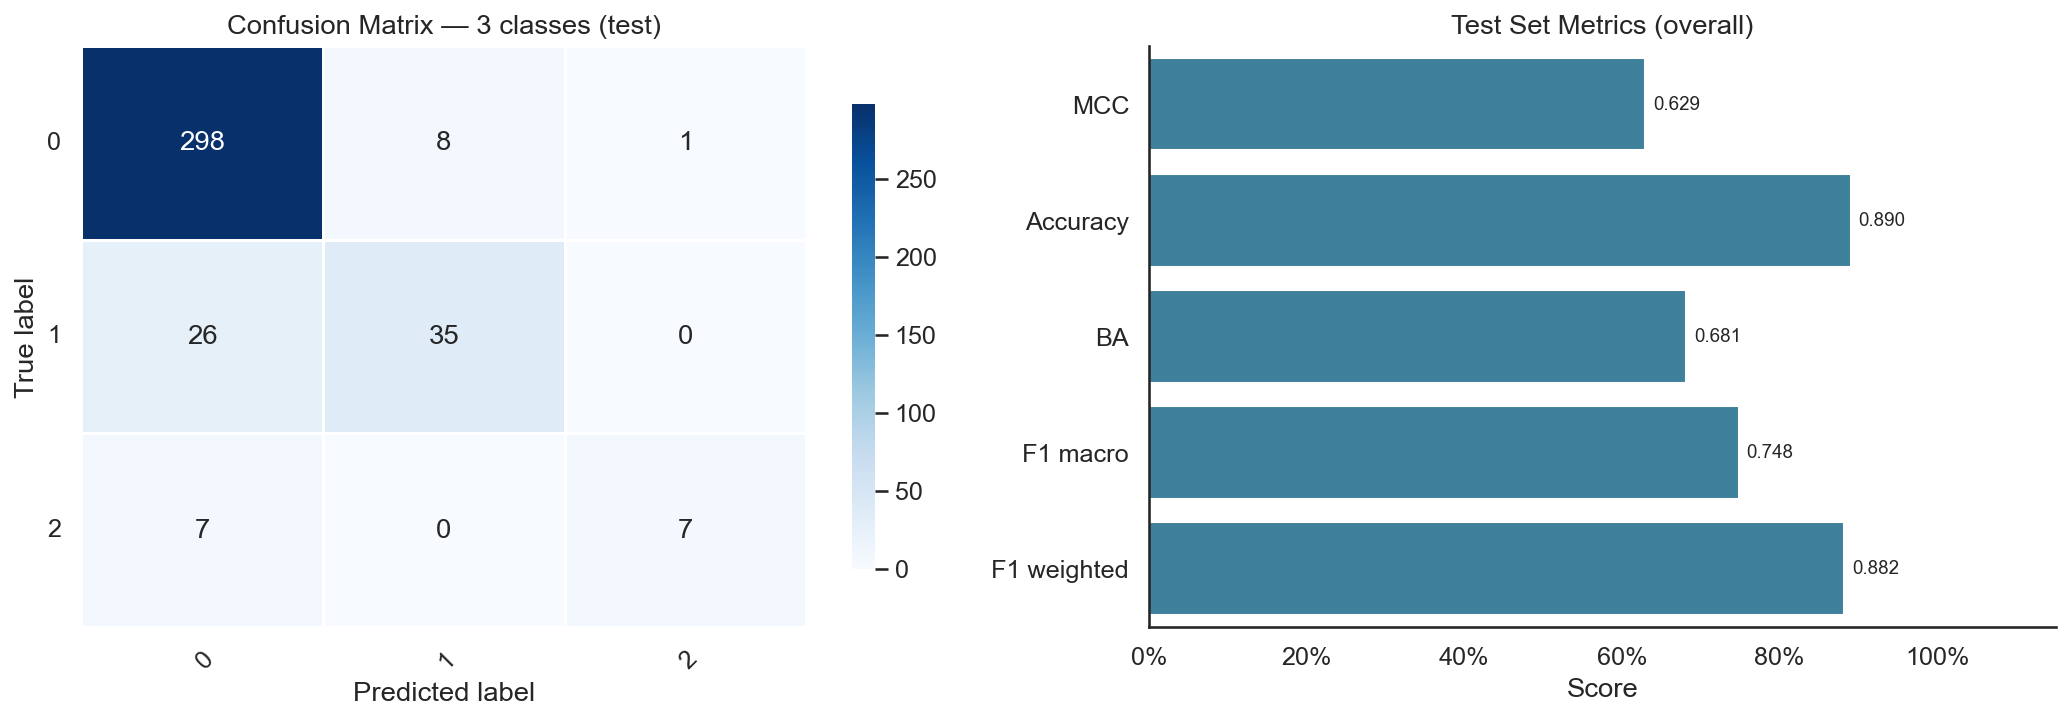

In [45]:
_n_classes  = len(set(y_test))
_is_binary  = _n_classes == 2

# binary eval → flat dict; multiclass eval → nested, scalars in "overall_metrics"
_test_metrics = model_result["test_evaluation"]
_scalar_metrics = _test_metrics.get("overall_metrics", _test_metrics)

if _is_binary:
    fig, axes = plt.subplots(1, 3, figsize=(17, 5))
    plot_confusion_matrix(
        y_test, y_pred,
        title="Confusion Matrix (test)", ax=axes[0],
    )
    plot_roc_curve(
        y_test, [p[1] for p in y_proba],
        title="ROC Curve (test)", ax=axes[1],
    )
    plot_pr_curve(
        y_test, [p[1] for p in y_proba],
        title="Precision-Recall Curve (test)", ax=axes[2],
    )
else:
    # Multiclass: confusion matrix + overall metric bar
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    plot_confusion_matrix(
        y_test, y_pred,
        title=f"Confusion Matrix — {_n_classes} classes (test)", ax=axes[0],
    )
    plot_metric_bar(_scalar_metrics, title="Test Set Metrics (overall)", ax=axes[1])

fig.tight_layout()
plt.show()

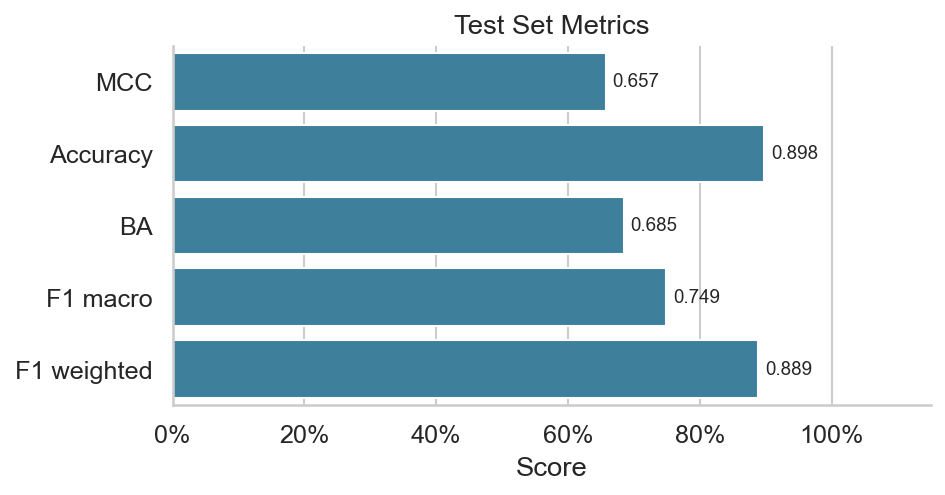

In [26]:
# Evaluation metrics bar chart
# binary eval → flat dict; multiclass eval → nested, scalars in "overall_metrics"
_eval = model_result["test_evaluation"]
_scalars = _eval.get("overall_metrics", _eval)
plot_metric_bar(_scalars, title="Test Set Metrics")
plt.show()

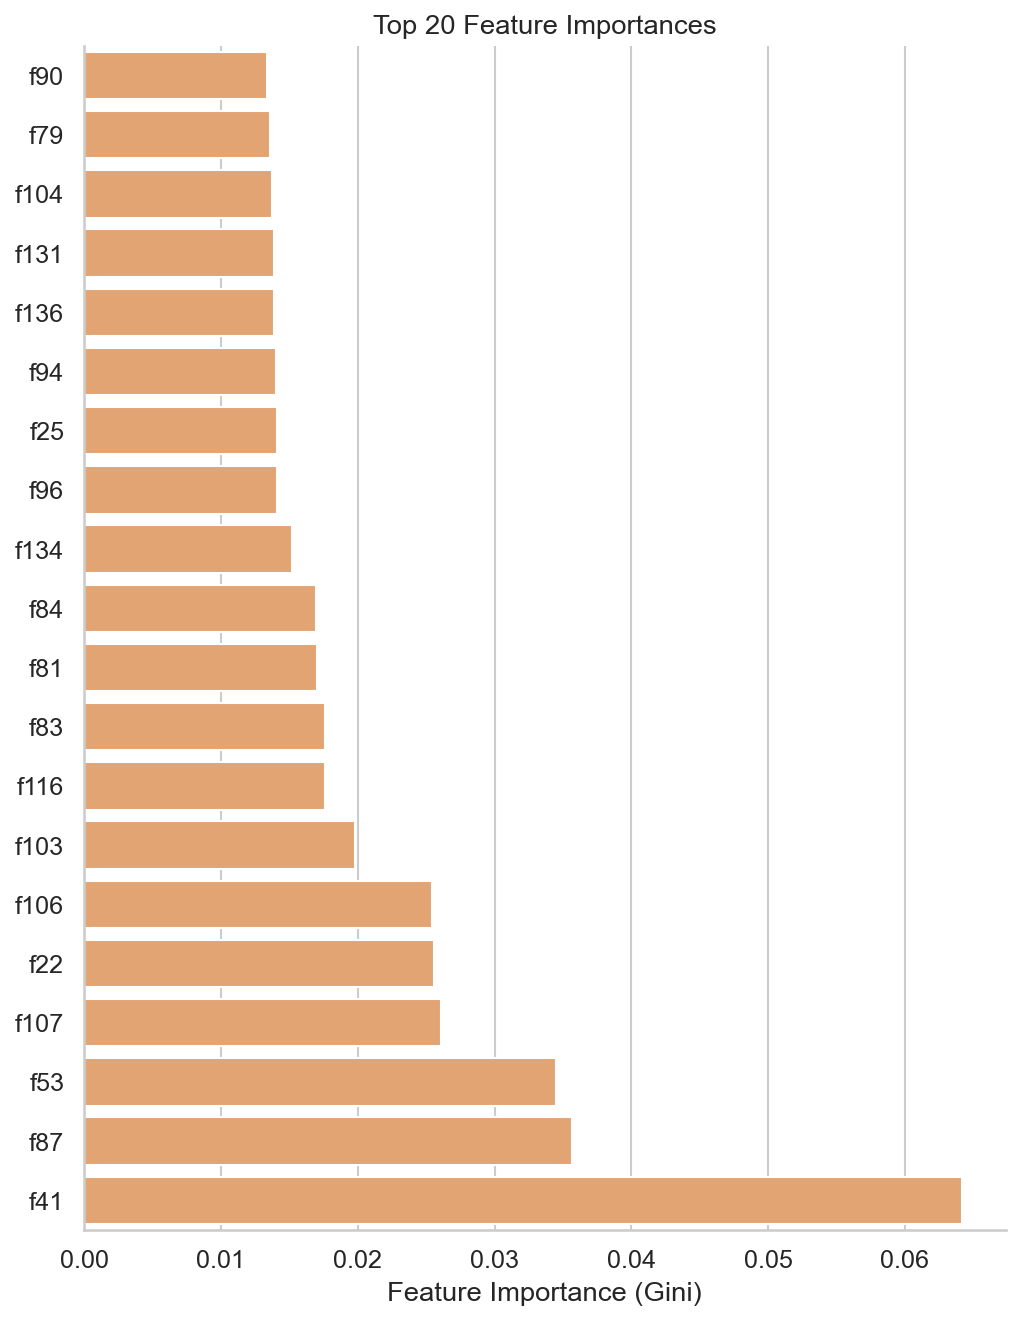

In [27]:
# Top-20 feature importances (RFC / tree-based models only)
_model = joblib.load(model_result["model_path"])
plot_feature_importance(_model, top_n=20, title="Top 20 Feature Importances")
plt.show()

## 10. Scratch / exploratory

{'algorithm': 'RFC',
 'class_labels': [0, 1, 2],
 'confusion_matrix': [[301, 4, 2], [26, 35, 0], [7, 0, 7]],
 'overall_metrics': {'Accuracy': 0.8979057591623036,
                     'BA': 0.6847421726206369,
                     'F1 macro': 0.7492844061588549,
                     'F1 weighted': 0.8888563140977723,
                     'MCC': 0.6568323196779525},
 'per_class_metrics': {'Class_0': {'F1': 0.9391575663026521,
                                   'Precision': 0.9011976047904192,
                                   'Recall': 0.9804560260586319,
                                   'Support': 307},
                       'Class_1': {'F1': 0.7,
                                   'Precision': 0.8974358974358975,
                                   'Recall': 0.5737704918032787,
                                   'Support': 61},
                       'Class_2': {'F1': 0.6086956521739131,
                                   'Precision': 0.7777777777777778,
                            